<a href="https://colab.research.google.com/github/yassafbd/Introduction-to-Cloud-Computing/blob/main/ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests beautifulsoup4
import requests
from bs4 import BeautifulSoup

def fetch_page(url):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        )
    }



    try:
        response = requests.get(url, headers=headers)
        print("HTTP status:", response.status_code)

        if response.status_code == 200:
            soup = BeautifulSoup(response.text, "html.parser")
            return soup
        else:
            print("Response head:", response.text[:200])
            return None

    except Exception as e:
        print("Request error:", e)
        return None


In [ ]:
import re
def index_words(soup):
  index = {}
  words = re.findall(r'\w+', soup.get_text())
  for word in words:
    word = word.lower()
    if word in index:
      index[word] += 1
    else:
      index[word] = 1
  return index

In [ ]:
def remove_stop_words(index):
  stop_words = {'a', 'an', 'the', 'and', 'or', 'in', 'on', 'at'}
  for stop_word in stop_words:
    if stop_word in index:
      del index[stop_word]
  return index

In [ ]:
from nltk.stem import PorterStemmer
def apply_stemming(index):
  stemmer = PorterStemmer()
  stemmed_index = {}
  for word, count in index.items():
    stemmed_word = stemmer.stem(word)
    if stemmed_word in stemmed_index:
      stemmed_index[stemmed_word] += count
    else:
      stemmed_index[stemmed_word] = count
  return stemmed_index

In [ ]:
def search(query, index):
  query_words = re.findall(r'\w+', query.lower())
  results = {}
  for word in query_words:
    if word in index:
      results[word] = index[word]
  return results

In [ ]:
def search_engine(url, query):
  soup = fetch_page(url)
  if soup is None:
     return None
  index = index_words(soup)
  index = remove_stop_words(index)
  index = apply_stemming(index)
  results = search(query, index)
  return results

In [ ]:
url = 'https://en.wikipedia.org/wiki/Bird'
query = 'bird'
results = search_engine(url, query)
print(results)

HTTP status: 200
{'bird': 577}


In [ ]:
url = 'https://en.wikipedia.org/wiki/Bird'
query = 'birds wings'
results = search_engine(url, query)
print(results)

HTTP status: 200
{}


In [ ]:
def search(query, index):
  stemmer = PorterStemmer()
  query_words = re.findall(r'\w+', query.lower())
  results = {}
  for word in query_words:
    word = stemmer.stem(word)
    if word in index:
      results[word] = index[word]
  return results

In [ ]:
url = 'https://en.wikipedia.org/wiki/Bird'
query = 'birds wings'
results = search_engine(url, query)
print(results)

HTTP status: 200
{'bird': 577, 'wing': 25}


In [ ]:
rank=1
for word, count in results.items():
 rank = rank*1/count
rank = 1-rank


In [ ]:
url = 'https://en.wikipedia.org/wiki/Bird'
query = 'birds wings'
results = search_engine(url, query)
print(results)
rank=1
for word, count in results.items():
   rank = rank*1/count
rank = 1-rank
print(rank)

HTTP status: 200
{'bird': 577, 'wing': 25}
0.9999306759098787


In [ ]:
url = 'https://arxiv.org/abs/1604.03169'
query = 'Phytopathology, Image Processing, Deep Learning, Convolutional Neural Networks, Classification, Feature Extraction, Lesions, Dataset, Performance Evaluation, Precision Agriculture'
results = search_engine(url, query)
print(results)
rank=1
for word, count in results.items():
 rank = rank*1/count
rank = 1-rank
print(rank)


HTTP status: 200
{'imag': 8, 'deep': 7, 'learn': 9, 'convolut': 1, 'neural': 1, 'network': 1, 'classif': 2, 'featur': 1, 'dataset': 2}
0.9995039682539683


שומר נתונים ב-Firebase...
שולף נתונים מ-Firebase...
המושגים שנשלפו: ['agriculture', 'classification', 'convolutional', 'dataset', 'deep', 'feature', 'image', 'learning', 'lesions', 'performance', 'phytopathology', 'precision', 'processing']

--- תוצאות חיפוש עבור האתר: https://en.wikipedia.org/wiki/Plant_pathology ---
המילה 'agriculture' מופיעה 12 פעמים. קישור: https://en.wikipedia.org/wiki/Plant_pathology
המילה 'classification' מופיעה 1 פעמים. קישור: https://en.wikipedia.org/wiki/Plant_pathology
המילה 'convolutional' מופיעה 0 פעמים. קישור: https://en.wikipedia.org/wiki/Plant_pathology
המילה 'dataset' מופיעה 0 פעמים. קישור: https://en.wikipedia.org/wiki/Plant_pathology
המילה 'deep' מופיעה 0 פעמים. קישור: https://en.wikipedia.org/wiki/Plant_pathology
המילה 'feature' מופיעה 0 פעמים. קישור: https://en.wikipedia.org/wiki/Plant_pathology
המילה 'image' מופיעה 0 פעמים. קישור: https://en.wikipedia.org/wiki/Plant_pathology
המילה 'learning' מופיעה 0 פעמים. קישור: https://en.wikipedia.org/wiki/Pl

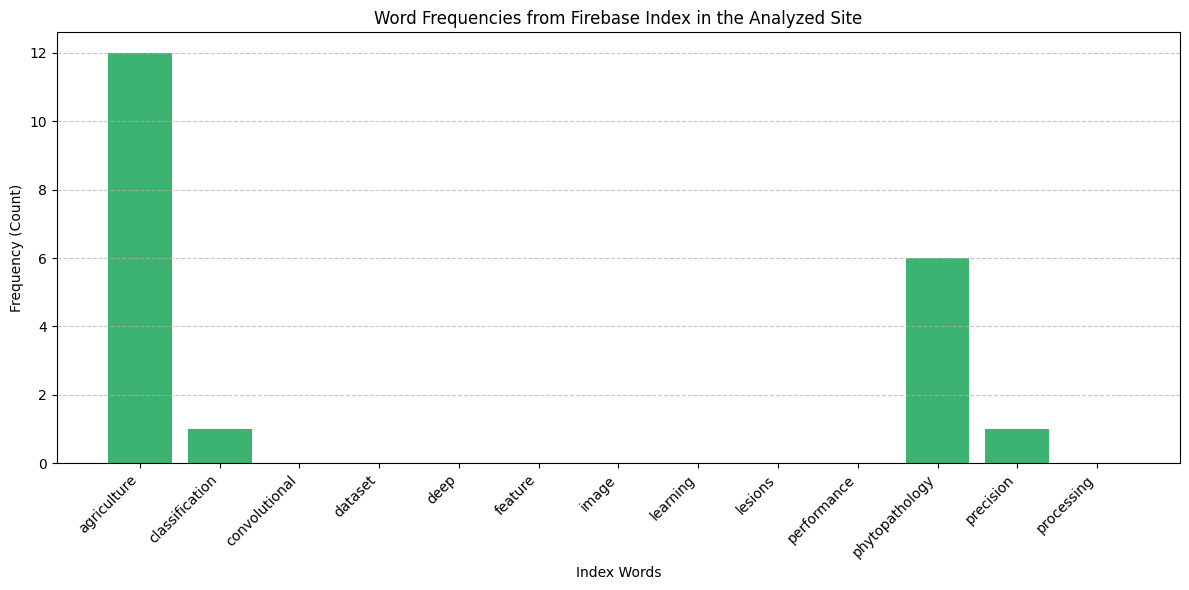

In [ ]:
# 1. התקנת ספריות נדרשות
!pip install firebase-admin requests beautifulsoup4 matplotlib

import firebase_admin
from firebase_admin import credentials, firestore
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# 2. התחברות ל-Firebase
# חובה: העלו את קובץ ה-JSON של הרשאות ה-Firebase שלכם לתיקיית הקבצים ב-Colab
# ושנו את השם בשורה הבאה לשם הקובץ שהעלתם:
cred = credentials.Certificate("/content/ex5-d768b-firebase-adminsdk-fbsvc-b6293c655b.json")

# אתחול האפליקציה (מונע שגיאות אם מריצים את התא פעמיים)
if not firebase_admin._apps:
    firebase_admin.initialize_app(cred)

db = firestore.client()
collection_name = 'plant_disease_index'

# 3. שמירת האינדקס ב-Firebase
terms_to_save = [
    "phytopathology", "image", "processing", "deep", "learning",
    "convolutional", "classification", "feature", "lesions", "dataset",
    "performance", "precision", "agriculture"
]
# הערה: פיצלתי חלק מהמושגים למילים בודדות כדי שיתאימו לפונקציית ה-regex שמחפשת מילים (w\+) בקוד המקורי שלכם

print("שומר נתונים ב-Firebase...")
for term in terms_to_save:
    # יצירת מסמך לכל מילה
    db.collection(collection_name).document(term).set({'word': term})

# 4. שליפת המילים מ-Firebase
print("שולף נתונים מ-Firebase...")
docs = db.collection(collection_name).stream()
fetched_terms = [doc.to_dict()['word'] for doc in docs]
print(f"המושגים שנשלפו: {fetched_terms}")

# 5. שימוש בפונקציות החיפוש מתוך הקוד שלכם
def fetch_page(url):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        )
    }
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return BeautifulSoup(response.text, "html.parser")
    except Exception as e:
        print("Request error:", e)
    return None

def index_words(soup):
    index = {}
    words = re.findall(r'\w+', soup.get_text())
    for word in words:
        word = word.lower()
        if word in index:
            index[word] += 1
        else:
            index[word] = 1
    return index

# 6. חיפוש המילים באתר ספציפי
target_url = 'https://en.wikipedia.org/wiki/Plant_pathology'
soup = fetch_page(target_url)

word_frequencies = {}

if soup:
    # יצירת אינדקס מילים מהאתר הספציפי באמצעות הפונקציה שלכם
    site_index = index_words(soup)
    print(f"\n--- תוצאות חיפוש עבור האתר: {target_url} ---")

    for term in fetched_terms:
        # בדיקת כמות המופעים של כל מילה מה-Firebase בתוך האינדקס של האתר
        count = site_index.get(term, 0)
        word_frequencies[term] = count
        print(f"המילה '{term}' מופיעה {count} פעמים. קישור: {target_url}")

# 7. הצגת גרף (Chart) של כמות המופעים
plt.figure(figsize=(12, 6))
plt.bar(word_frequencies.keys(), word_frequencies.values(), color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.title('Word Frequencies from Firebase Index in the Analyzed Site')
plt.xlabel('Index Words')
plt.ylabel('Frequency (Count)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- מיפוי מילים לקישורים ---
המילה: 'agriculture'
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Plant_pathology
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Precision_agriculture
------------------------------
המילה: 'classification'
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Plant_pathology
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Deep_learning
------------------------------
המילה: 'convolutional'
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Deep_learning
------------------------------
המילה: 'dataset'
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Deep_learning
------------------------------
המילה: 'deep'
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Deep_learning
------------------------------
המילה: 'feature'
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Precision_agriculture
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Deep_learning
------------------------------
המילה: 'image'
  🔗 נמצאה בקישור: https://en.wikipedia.org/wiki/Precision_agriculture
  🔗 נמ

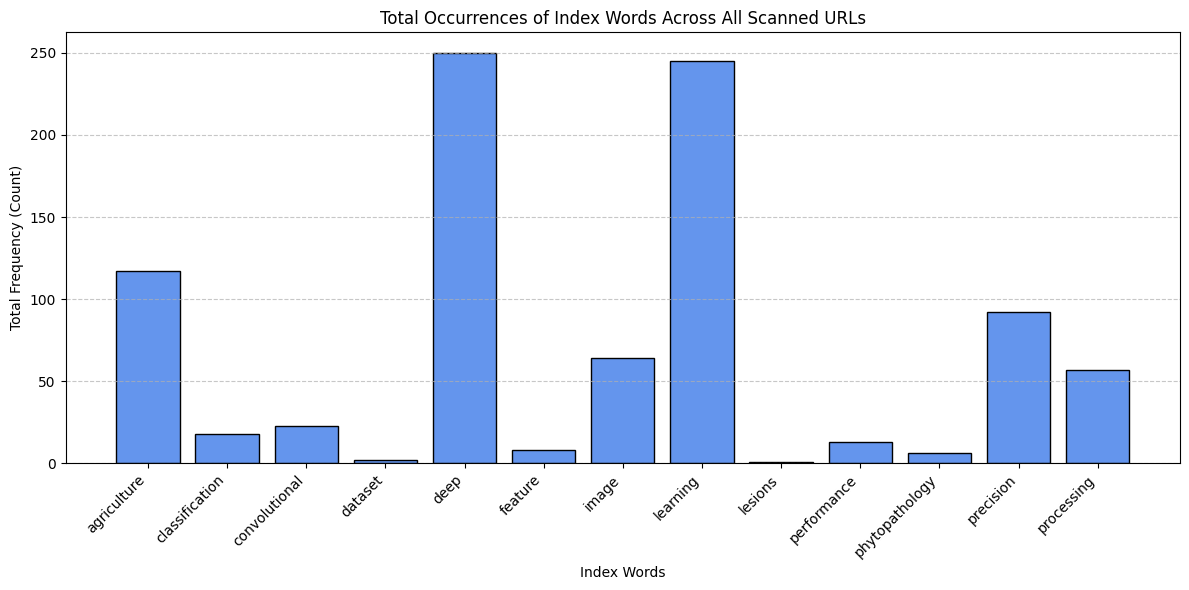

In [ ]:
import firebase_admin
from firebase_admin import credentials, firestore
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# 1. חיבור ל-Firebase (במידה וצריך אתחול מחדש)
if not firebase_admin._apps:
    # זכור לשנות לשם הקובץ של ה-JSON שלך
    cred = credentials.Certificate("path_to_your_firebase_credentials.json")
    firebase_admin.initialize_app(cred)

db = firestore.client()
collection_name = 'plant_disease_index'

# 2. שליפת המילים מ-Firebase (מהאינדקס)
docs = db.collection(collection_name).stream()
fetched_terms = [doc.to_dict()['word'] for doc in docs]

# 3. פונקציות סריקת האתרים (מבוסס על הקוד שכתבתם)
def fetch_page(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return BeautifulSoup(response.text, "html.parser")
    except Exception as e:
        pass
    return None

def index_words(soup):
    index = {}
    words = re.findall(r'\w+', soup.get_text())
    for word in words:
        word = word.lower()
        index[word] = index.get(word, 0) + 1
    return index

# נגדיר מספר קישורים שמייצגים את ה"אתר" / מקורות המידע שלנו
urls_to_scan = [
    'https://en.wikipedia.org/wiki/Plant_pathology',
    'https://en.wikipedia.org/wiki/Precision_agriculture',
    'https://en.wikipedia.org/wiki/Deep_learning'
]

# מילונים לשמירת הנתונים: היכן כל מילה הופיעה, וכמה פעמים בסך הכל
word_to_links = {term: [] for term in fetched_terms}
word_total_counts = {term: 0 for term in fetched_terms}

# 4. סריקת הקישורים ומיפוי המילים
for url in urls_to_scan:
    soup = fetch_page(url)
    if soup:
        site_index = index_words(soup)
        for term in fetched_terms:
            count_in_page = site_index.get(term, 0)
            if count_in_page > 0:
                word_to_links[term].append(url)          # שמירת הקישור
                word_total_counts[term] += count_in_page # הוספה לספירה הכוללת

# ==========================================
# 5. הצגת כל מילה יחד עם הקישורים (פלט טקסטואלי)
# ==========================================
print("--- מיפוי מילים לקישורים ---")
for term in fetched_terms:
    links = word_to_links[term]
    if links:
        print(f"המילה: '{term}'")
        for link in links:
            print(f"  🔗 נמצאה בקישור: {link}")
    else:
        print(f"המילה: '{term}' לא נמצאה באתרים שנסרקו.")
    print("-" * 30)

# ==========================================
# 6. הצגת Chart המייצג את כמות המופעים באתר כולו
# ==========================================
plt.figure(figsize=(12, 6))
# שימוש בנתוני הספירה הכוללת שאספנו
plt.bar(word_total_counts.keys(), word_total_counts.values(), color='cornflowerblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Total Occurrences of Index Words Across All Scanned URLs')
plt.xlabel('Index Words')
plt.ylabel('Total Frequency (Count)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# הצגת הגרף
plt.show()

In [ ]:
url = 'https://en.wikipedia.org/wiki/Bird'
query = 'owls'
results = search_engine(url, query)
print(results)
rank=1
for word, count in results.items():
 rank = rank*1/count
rank = 1-rank
print(rank)

{'owl': 13}
0.9230769230769231


In [ ]:
url = 'https://en.wikipedia.org/wiki/Bird'
query = 'Industry'
results = search_engine(url, query)
print(results)
rank=1
for word, count in results.items():
 rank = rank*1/count
rank = 1-rank
print(rank)

{'industri': 3}
0.6666666666666667




```
# This is formatted as code
```

### **מנוע המיועד למספר דפים**

In [ ]:
import requests
from bs4 import BeautifulSoup
import re
from collections import defaultdict
class WikiSearchEngine:
  def __init__(self):
    """Initialize the search engine"""
    self.base_url = "https://en.wikipedia.org/w/api.php"
    self.pages = []
    self.word_locations = defaultdict(list) # word -> [(page_id, frequency), ...]
    self.stop_words = {'a', 'an', 'the', 'and', 'or', 'in', 'on', 'at', 'to', 'for', 'of', 'with'}
    return False
  def fetch_wiki_pages(self, topic, num_pages=5):
    """Fetch Wikipedia pages for given topic"""
    search_params = {
      "action": "query",
      "format": "json",
      "list": "search",
      "srsearch": topic,
      "srlimit": num_pages
    }
    try:
      response = requests.get(self.base_url, params=search_params)
      search_results = response.json()['query']['search']

      for result in search_results:
        content_params = {
            "action": "query",
            "format": "json",
            "prop": "extracts|info",
            "pageids": result['pageid'],
            "inprop": "url",
            "explaintext": True
        }
        content_response = requests.get(self.base_url, params=content_params)
        page_data = content_response.json()['query']['pages'][str(result['pageid'])]
        self.pages.append({
          'id': result['pageid'],
          'title': page_data['title'],
          'url': page_data.get('fullurl', f"https://en.wikipedia.org/?curid={result['pageid']}"),
          'content': page_data['extract']
        })
      print(f"Retrieved: {page_data['title']}")
      return True

    except Exception as e:
      print(f"Error fetching pages: {str(e)}")

  def build_index(self):
        """Build a simple word location index"""
        self.word_locations.clear()

        # Process each page
        for page in self.pages:
            # Get all words from content
            words = re.findall(r'\w+', page['content'].lower())

            # Count word frequencies
            word_counts = defaultdict(int)
            for word in words:
                if word not in self.stop_words:
                    word_counts[word] += 1

            # Add to index with page information
            for word, count in word_counts.items():
                self.word_locations[word].append((page['id'], count))

  def search(self, query, num_results=5):
        """Search pages using simple word frequency ranking.
        Ranks pages based on:1. Number of query words found in the page
        2. Total frequency of query words  """
        # Get query words
        query_words = [word.lower() for word in re.findall(r'\w+', query)
                    if word.lower() not in self.stop_words]
        if not query_words:
            return []

        # Calculate scores for each page
        page_scores = defaultdict(lambda: {'matches': 0, 'total_freq': 0})

        # For each query word
        for word in query_words:
            # Find pages containing this word
            for page_id, freq in self.word_locations.get(word, []):
                page_scores[page_id]['matches'] += 1
                page_scores[page_id]['total_freq'] += freq


        # Convert to list and sort
        ranked_results = [
            (page_id, scores['matches'], scores['total_freq'])
            for page_id, scores in page_scores.items()
        ]
        # Sort by number of matching words first, then by total frequency
        ranked_results.sort(key=lambda x: (x[1], x[2]), reverse=True)
        # Format results
        results = []
        for page_id, matches, total_freq in ranked_results[:num_results]:
            page = next(p for p in self.pages if p['id'] == page_id)
            # Find the first matching word context
            context = self.get_context(page['content'], query_words)
            results.append({
                'title': page['title'],
                'url': page['url'],
                'matching_words': matches,
                'total_frequency': total_freq,
                'context': context
            })
        return results


In [ ]:
def fetch_wiki_pages(self, topic, num_pages=5):
  """Fetch Wikipedia pages for given topic"""
  search_params = {
  "action": "query",
  "format": "json",
  "list": "search",
  "srsearch": topic,
  "srlimit": num_pages
  }
  try:
      response = requests.get(self.base_url, params=search_params)
      search_results = response.json()['query']['search']

      for result in search_results:
        content_params = {
            "action": "query",
            "format": "json",
            "prop": "extracts|info",
            "pageids": result['pageid'],
            "inprop": "url",
            "explaintext": True
        }
        content_response = requests.get(self.base_url, params=content_params)
        page_data = content_response.json()['query']['pages'][str(result['pageid'])]
        self.pages.append({
          'id': result['pageid'],
          'title': page_data['title'],
          'url': page_data.get('fullurl', f"https://en.wikipedia.org/?curid={result['pageid']}"),
          'content': page_data['extract']
        })
        print(f"Retrieved: {page_data['title']}")
      return True

  except Exception as e:
    print(f"Error fetching pages: {str(e)}")


In [ ]:
    def build_index(self):
        """Build a simple word location index"""
        self.word_locations.clear()

        # Process each page
        for page in self.pages:
            # Get all words from content
            words = re.findall(r'\w+', page['content'].lower())

            # Count word frequencies
            word_counts = defaultdict(int)
            for word in words:
                if word not in self.stop_words:
                    word_counts[word] += 1

            # Add to index with page information
            for word, count in word_counts.items():
                self.word_locations[word].append((page['id'], count))

    def search(self, query, num_results=5):
        """Search pages using simple word frequency ranking.
        Ranks pages based on:1. Number of query words found in the page
        2. Total frequency of query words  """
        # Get query words
        query_words = [word.lower() for word in re.findall(r'\w+', query)
                      if word.lower() not in self.stop_words]
        if not query_words:
            return []

        # Calculate scores for each page
        page_scores = defaultdict(lambda: {'matches': 0, 'total_freq': 0})

        # For each query word
        for word in query_words:
            # Find pages containing this word
            for page_id, freq in self.word_locations.get(word, []):
                page_scores[page_id]['matches'] += 1
                page_scores[page_id]['total_freq'] += freq


        # Convert to list and sort
        ranked_results = [
            (page_id, scores['matches'], scores['total_freq'])
            for page_id, scores in page_scores.items()
        ]
        # Sort by number of matching words first, then by total frequency
        ranked_results.sort(key=lambda x: (x[1], x[2]), reverse=True)
        # Format results
        results = []
        for page_id, matches, total_freq in ranked_results[:num_results]:
            page = next(p for p in self.pages if p['id'] == page_id)
            # Find the first matching word context
            context = self.get_context(page['content'], query_words)
            results.append({
                'title': page['title'],
                'url': page['url'],
                'matching_words': matches,
                'total_frequency': total_freq,
                'context': context
            })
        return results